# Lecture 2 · Part 2
# Bounded Autonomy in Treasury — An Autonomous Liquidity Desk

**Alejandro Reynoso · AI for Financial Practitioners · Master of Finance · Michaelmas 2026**

## The experiment

A multinational treasury desk must keep several operating entities liquid through the next five business days while minimizing unnecessary external funding and respecting explicit institutional constraints. The environment is synthetic, but the institutional problem is recognizable: cash sits in different entities and currencies; payroll, tax, supplier and debt-service obligations arrive on different dates; expected receipts can be delayed; credit facilities have limits and costs; and some actions are routine while others require a Treasurer.

The notebook deliberately separates **intelligence from authority**. Claude Haiku 4.5 is used by a small constellation of specialist agents to interpret the state, forecast liquidity pressure, generate candidate actions, challenge risks and assemble a coherent treasury plan. Those agents can reason, disagree and recommend. They cannot change the mandate. A deterministic action gateway decides whether a proposed consequence is inside the institution's delegated authority.

The same environment is then run under three architectures:

1. **Advice** — the AI system diagnoses and recommends, but cannot alter the ledger.
2. **Approval** — the system prepares an executable package, but every action waits for simulated Treasurer approval.
3. **Bounded autonomy** — routine actions inside the mandate may execute automatically; actions outside the mandate are escalated.

The important comparison is therefore not “human versus AI.” It is **the same analytical capability operating under different institutional delegation arrangements**.

A mid-session shock makes the system dynamic: a large UK customer receipt is delayed by 48 hours while Mexican payroll is brought forward. The desk must observe the changed state, re-plan, validate, act where authorized, escalate where necessary, and reconcile the resulting ledger.

All balances, entities, obligations and market data are synthetic. No bank, broker, payment rail or production system is connected. All “execution” is an in-memory simulation.

## Architecture of the autonomous desk

The notebook models a small institutional constellation rather than a single omnipotent agent.

- **Liquidity Agent** — identifies projected cash deficits and surpluses by entity and date.
- **Funding Agent** — compares internal liquidity with revolver funding.
- **FX Agent** — identifies currency mismatches and proposes bounded conversions when useful.
- **Risk Agent** — challenges concentration, buffer, stale-state and limit risks.
- **Policy Agent** — maps candidate actions to the written mandate; it advises but does not authorize.
- **Supervisor Agent** — synthesizes the specialist outputs into a proposed action package.
- **Deterministic Action Gateway** — validates every proposed consequence against executable rules.
- **Treasurer** — owns the mandate, approves escalations and can revoke authority.

Agents communicate through structured objects: **state → forecasts → specialist assessments → proposed plan → gateway decisions → receipts → updated state**. This is intentional. Free-form conversation may help explanation, but institutional action requires inspectable objects with stable fields.

The notebook contains ten executable cells. Run them in order. Set `LIVE_LLM=False` in Cell 1 for a deterministic classroom rehearsal. In live mode, add `ANTHROPIC_API_KEY` to Colab Secrets and enable notebook access.

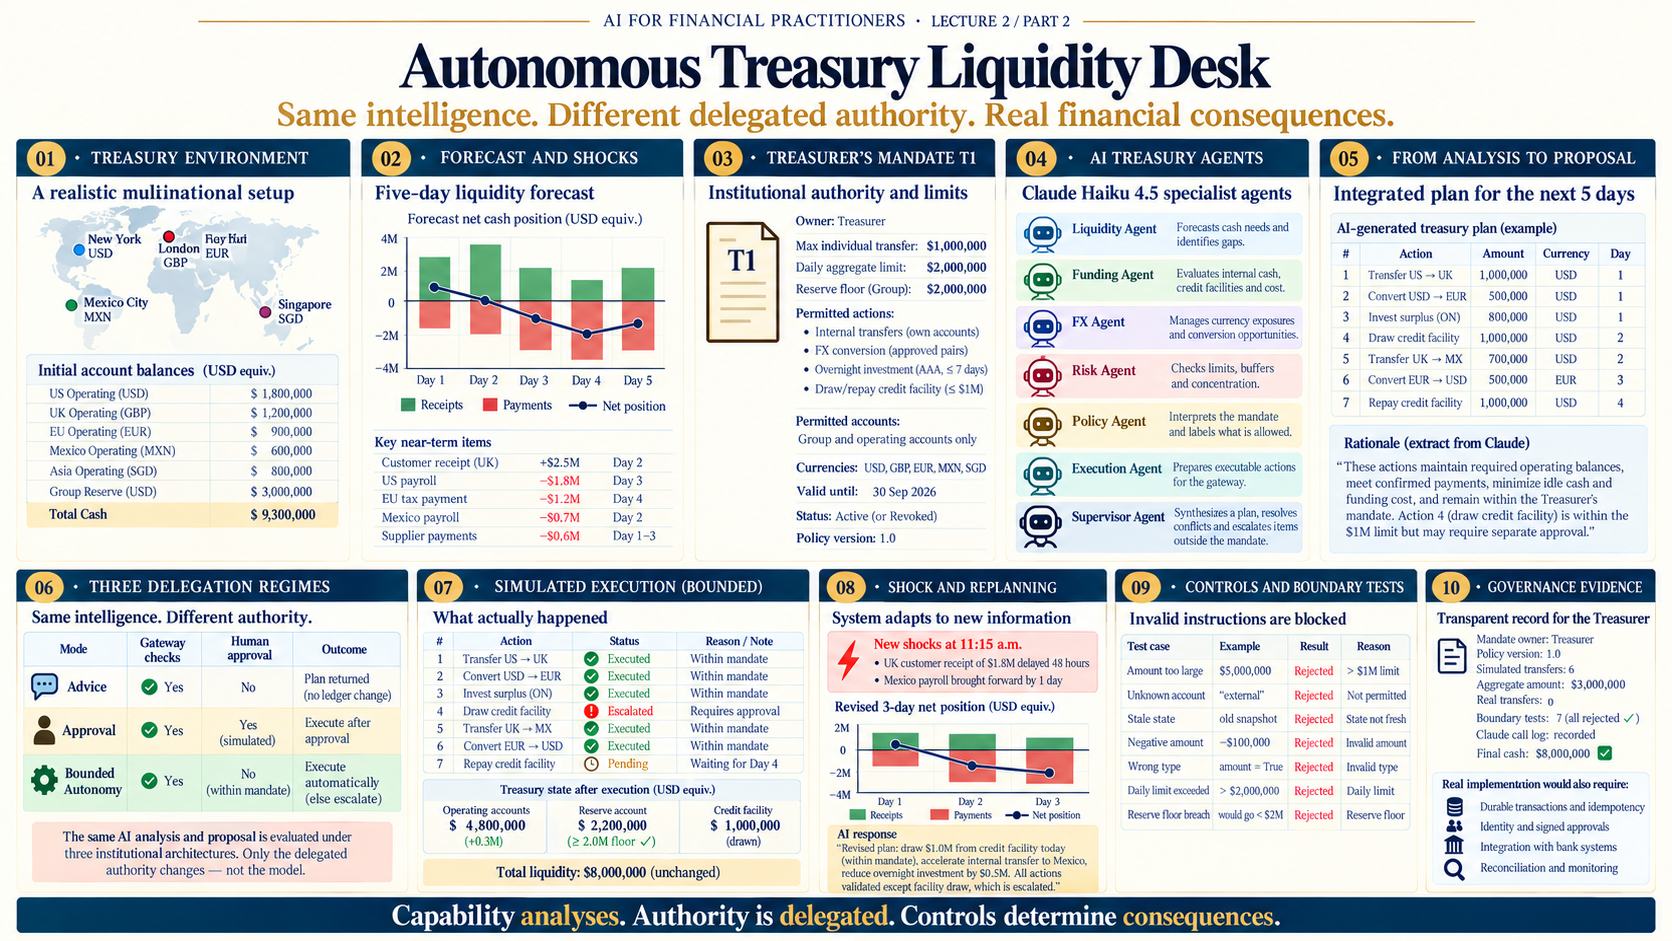

## Cell 1 — Configure a bounded experiment

This cell establishes the model, the execution mode and a small call budget. CPU is sufficient. Live mode uses `claude-haiku-4-5-20251001`; offline mode uses explicitly authored fixtures so that the deterministic treasury machinery can be rehearsed without an API connection. Switching mode changes the experiment and should be followed by a runtime restart.

In [2]:
# @title
# CELL 1 — Environment and experiment configuration
import importlib.util, subprocess, sys, json, copy, time, hashlib, math
from datetime import date, timedelta
from collections import defaultdict
import pandas as pd
from IPython.display import display, Markdown

for package in ("anthropic", "pandas"):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

LIVE_LLM = True          # False = deterministic classroom fixtures
MODEL = "claude-haiku-4-5-20251001"
MAX_CALLS = 24
CALL_LOG = []
TODAY = date(2026, 11, 10)

print("Mode:", "LIVE Claude Haiku 4.5" if LIVE_LLM else "OFFLINE FIXTURES — not model responses")
print("Valuation date:", TODAY.isoformat())

Mode: LIVE Claude Haiku 4.5
Valuation date: 2026-11-10


## Cell 2 — Create one controlled interface to Claude

Every specialist uses the same bounded helper. The model receives only synthetic evidence relevant to its assigned responsibility. Structured output is requested through Anthropic tool use, but the returned JSON is still only a **proposal**. No model response is trusted as authorization. API errors stop visibly; the notebook never silently substitutes a heuristic and pretends it came from Claude.

In [7]:
# CELL 2 — Claude interface: robust structured calls, bounded and explicit

client = None

if LIVE_LLM:
    from google.colab import userdata
    from anthropic import Anthropic

    try:
        api_key = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        raise RuntimeError(
            "Add ANTHROPIC_API_KEY in Colab Secrets and enable notebook access."
        ) from None

    if not api_key:
        raise RuntimeError("ANTHROPIC_API_KEY is empty.")

    client = Anthropic(
        api_key=api_key,
        timeout=90.0,
        max_retries=2
    )
    del api_key


def ask_agent(role, task, evidence, fixture, schema=None):
    """
    Bounded Claude call for the treasury-agent architecture.

    - Uses Claude Haiku 4.5.
    - Offline fixtures are explicit, never silent fallbacks.
    - Structured outputs use forced tool calling.
    - Financial execution authority remains outside the model.
    """

    if len(CALL_LOG) >= MAX_CALLS:
        raise RuntimeError(
            "Claude call budget exhausted. Restart the runtime for a new experiment."
        )

    # ------------------------------------------------------------
    # OFFLINE CLASSROOM MODE
    # ------------------------------------------------------------
    if not LIVE_LLM:
        CALL_LOG.append({
            "role": role,
            "mode": "offline fixture",
            "input_tokens": 0,
            "output_tokens": 0
        })
        return copy.deepcopy(fixture)

    # ------------------------------------------------------------
    # SYSTEM INSTRUCTION
    # ------------------------------------------------------------
    system_prompt = (
        f"You are the {role} in a synthetic multinational treasury simulation. "
        "Use ONLY the supplied evidence. "
        "Do not invent balances, rates, limits, approvals, transactions, "
        "credentials, market observations, or execution. "
        "Distinguish observations from recommendations. "
        "You have NO authority to execute financial actions. "
        "Be concise. "
        "When structured output is requested, return the requested structure "
        "directly and keep narrative fields brief."
    )

    user_payload = {
        "task": task,
        "evidence": evidence
    }

    kwargs = {
        "model": MODEL,
        "max_tokens": 3000,
        "system": system_prompt,
        "messages": [
            {
                "role": "user",
                "content": json.dumps(
                    user_payload,
                    default=str,
                    separators=(",", ":")
                )
            }
        ]
    }

    # ------------------------------------------------------------
    # FORCE STRUCTURED OUTPUT WHEN A SCHEMA IS PROVIDED
    # ------------------------------------------------------------
    if schema is not None:
        kwargs["tools"] = [
            {
                "name": "submit_result",
                "description": (
                    "Return the requested structured treasury result. "
                    "Use only supplied evidence."
                ),
                "input_schema": schema
            }
        ]

        kwargs["tool_choice"] = {
            "type": "tool",
            "name": "submit_result"
        }

    # ------------------------------------------------------------
    # API CALL
    # ------------------------------------------------------------
    started = time.monotonic()

    try:
        response = client.messages.create(**kwargs)

    except Exception as exc:
        CALL_LOG.append({
            "role": role,
            "mode": "API error",
            "error_type": type(exc).__name__,
            "input_tokens": 0,
            "output_tokens": 0
        })

        raise RuntimeError(
            f"Claude request failed for {role}: "
            f"{type(exc).__name__}. "
            "Check model access, Colab Secret access, connectivity, "
            "and Anthropic account limits. "
            "No fallback model or heuristic was substituted."
        ) from exc

    elapsed = round(time.monotonic() - started, 2)

    CALL_LOG.append({
        "role": role,
        "mode": "live",
        "model": response.model,
        "stop_reason": response.stop_reason,
        "seconds": elapsed,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens
    })

    # ------------------------------------------------------------
    # STRUCTURED RESPONSE
    # ------------------------------------------------------------
    if schema is not None:

        tool_blocks = [
            block
            for block in response.content
            if getattr(block, "type", None) == "tool_use"
            and getattr(block, "name", None) == "submit_result"
        ]

        # Important:
        # First inspect whether Claude produced a complete structured object.
        # Do not discard a valid tool result merely because the API reports
        # a token boundary elsewhere in the response.
        if len(tool_blocks) == 1:
            result = tool_blocks[0].input

            if not isinstance(result, dict):
                raise RuntimeError(
                    f"{role} returned a structured result "
                    "that is not a dictionary."
                )

            return result

        # No usable structured object was produced.
        if response.stop_reason == "max_tokens":
            raise RuntimeError(
                f"{role} exhausted the 3000-token output budget "
                "before producing a complete structured result. "
                "The response was rejected; no substitute was used."
            )

        raise RuntimeError(
            f"{role} did not return exactly one submit_result object. "
            f"stop_reason={response.stop_reason!r}"
        )

    # ------------------------------------------------------------
    # TEXT RESPONSE
    # ------------------------------------------------------------
    text_blocks = [
        block.text
        for block in response.content
        if getattr(block, "type", None) == "text"
    ]

    text = "\n".join(text_blocks).strip()

    if response.stop_reason == "max_tokens":
        raise RuntimeError(
            f"{role} text response was truncated and has been rejected."
        )

    if not text:
        raise RuntimeError(
            f"{role} returned no usable text."
        )

    return text


print(
    "Claude boundary configured:",
    MODEL,
    "| structured output budget = 3000 tokens",
    "| no financial execution authority granted"
)

Claude boundary configured: claude-haiku-4-5-20251001 | structured output budget = 3000 tokens | no financial execution authority granted


## Cell 3 — Build the multinational treasury state and the Treasurer's mandate

The environment contains six synthetic accounts across the United States, United Kingdom, Mexico and the euro area. Obligations and expected receipts create a five-business-day liquidity problem. The mandate is separate from the state: it defines what the autonomous desk may do, including approved entities, maximum internal transfer size, maximum revolver draw, maximum FX conversion, minimum post-action liquidity buffers, daily aggregate limits and expiry.

The mandate is executable institutional policy. Agents may quote it, reason about it and recommend changing it; they cannot change its values.

In [4]:
# @title
# CELL 3 — Synthetic treasury state + executable mandate
FX_TO_USD = {"USD":1.00, "GBP":1.27, "EUR":1.09, "MXN":0.058}

INITIAL_ACCOUNTS = {
    "US_OPER": {"entity":"US","currency":"USD","balance":1_150_000},
    "US_RESERVE": {"entity":"US","currency":"USD","balance":2_600_000},
    "UK_OPER": {"entity":"UK","currency":"GBP","balance":420_000},
    "MX_OPER": {"entity":"MX","currency":"MXN","balance":7_800_000},
    "EU_OPER": {"entity":"EU","currency":"EUR","balance":510_000},
    "GROUP_LIQ": {"entity":"GROUP","currency":"USD","balance":900_000},
}

OBLIGATIONS = [
    {"id":"US_SUPPLIERS","day":1,"account":"US_OPER","amount":650_000,"currency":"USD","kind":"suppliers"},
    {"id":"MX_PAYROLL","day":2,"account":"MX_OPER","amount":8_900_000,"currency":"MXN","kind":"payroll"},
    {"id":"UK_TAX","day":2,"account":"UK_OPER","amount":610_000,"currency":"GBP","kind":"tax"},
    {"id":"EU_PAYROLL","day":3,"account":"EU_OPER","amount":470_000,"currency":"EUR","kind":"payroll"},
    {"id":"US_DEBT","day":4,"account":"US_OPER","amount":1_050_000,"currency":"USD","kind":"debt_service"},
]

RECEIPTS = [
    {"id":"UK_CUSTOMER","day":1,"account":"UK_OPER","amount":520_000,"currency":"GBP","status":"expected"},
    {"id":"US_CUSTOMER","day":2,"account":"US_OPER","amount":900_000,"currency":"USD","status":"expected"},
    {"id":"EU_CUSTOMER","day":2,"account":"EU_OPER","amount":360_000,"currency":"EUR","status":"expected"},
    {"id":"MX_CUSTOMER","day":3,"account":"MX_OPER","amount":4_500_000,"currency":"MXN","status":"expected"},
]

MANDATE = {
    "version":"T2.0",
    "owner":"Group Treasurer",
    "active":True,
    "valid_through":"2026-12-31",
    "approved_accounts":list(INITIAL_ACCOUNTS.keys()),
    "internal_transfer_max_usd":750_000,
    "fx_conversion_max_usd":500_000,
    "revolver_draw_max_usd":600_000,
    "daily_autonomous_aggregate_usd":1_250_000,
    "minimum_buffer_usd":{
        "US":250_000, "UK":200_000, "MX":180_000, "EU":200_000, "GROUP":300_000
    },
    "approved_action_types":["TRANSFER","FX","DRAW"],
    "approval_required_if_usd_over":600_000,
    "revolver_limit_usd":2_000_000,
}

def fresh_state():
    return {
        "as_of":TODAY.isoformat(),
        "accounts":copy.deepcopy(INITIAL_ACCOUNTS),
        "obligations":copy.deepcopy(OBLIGATIONS),
        "receipts":copy.deepcopy(RECEIPTS),
        "revolver_drawn_usd":0,
        "autonomous_spent_usd":0,
        "receipts_log":[],
        "request_registry":{},
        "events":[]
    }

def usd_value(amount, currency):
    return round(amount * FX_TO_USD[currency], 2)

state0 = fresh_state()
display(pd.DataFrame([
    {"account":k, **v, "usd_equivalent":usd_value(v["balance"],v["currency"])}
    for k,v in state0["accounts"].items()
]))
display(pd.DataFrame([MANDATE]))

,account,entity,currency,balance,usd_equivalent
0,US_OPER,US,USD,1150000,1150000.0
1,US_RESERVE,US,USD,2600000,2600000.0
2,UK_OPER,UK,GBP,420000,533400.0
3,MX_OPER,MX,MXN,7800000,452400.0
4,EU_OPER,EU,EUR,510000,555900.0
5,GROUP_LIQ,GROUP,USD,900000,900000.0


,version,owner,active,valid_through,approved_accounts,internal_transfer_max_usd,fx_conversion_max_usd,revolver_draw_max_usd,daily_autonomous_aggregate_usd,minimum_buffer_usd,approved_action_types,approval_required_if_usd_over,revolver_limit_usd
0,T2.0,Group Treasurer,True,2026-12-31,"[US_OPER, US_RESERVE, UK_OPER, MX_OPER, EU_OPE...",750000,500000,600000,1250000,"{'US': 250000, 'UK': 200000, 'MX': 180000, 'EU...","[TRANSFER, FX, DRAW]",600000,2000000


## Cell 4 — Observe the baseline and then inject a genuine liquidity shock

The first analytical object is not an action but a **five-day liquidity forecast**. The Liquidity Agent receives balances, obligations and expected receipts and identifies pressure points. We then alter the environment: the UK customer receipt expected on Day 1 is delayed by 48 hours, while Mexican payroll is brought forward from Day 2 to Day 1. The system must recognize that yesterday's plan is no longer sufficient.

This creates the feedback loop that the earlier simple transfer example lacked: **observe → interpret → plan → act → observe again**.

In [5]:
# @title
# CELL 4 — Baseline forecast, shock, and re-observation
forecast_schema = {
    "type":"object",
    "properties":{
        "summary":{"type":"string"},
        "pressure_points":{"type":"array","items":{
            "type":"object",
            "properties":{
                "entity":{"type":"string"},
                "day":{"type":"integer"},
                "estimated_gap_usd":{"type":"number"},
                "reason":{"type":"string"}
            },
            "required":["entity","day","estimated_gap_usd","reason"],
            "additionalProperties":False
        }},
        "priority":{"type":"string"}
    },
    "required":["summary","pressure_points","priority"],
    "additionalProperties":False
}

baseline_fixture = {
    "summary":"Expected receipts cover much of the five-day need, but UK and MX are timing-sensitive.",
    "pressure_points":[
        {"entity":"UK","day":2,"estimated_gap_usd":0,"reason":"UK tax depends on expected customer receipt."},
        {"entity":"MX","day":2,"estimated_gap_usd":63800,"reason":"Payroll exceeds opening MX cash before later receipt."}
    ],
    "priority":"Protect payroll, tax and debt-service dates before optimizing idle liquidity."
}

baseline = ask_agent(
    "Liquidity Agent",
    "Forecast the next five business days. Identify timing gaps; do not propose execution yet.",
    {"accounts":state0["accounts"],"obligations":state0["obligations"],"receipts":state0["receipts"],
     "fx_to_usd":FX_TO_USD,"buffers":MANDATE["minimum_buffer_usd"]},
    baseline_fixture, forecast_schema
)
display(Markdown("### Baseline observation"))
display(baseline)

shock_state = fresh_state()
for r in shock_state["receipts"]:
    if r["id"] == "UK_CUSTOMER":
        r["day"] = 3
        r["status"] = "delayed_48h"
for o in shock_state["obligations"]:
    if o["id"] == "MX_PAYROLL":
        o["day"] = 1
shock_state["events"] += [
    "UK_CUSTOMER receipt delayed from Day 1 to Day 3",
    "MX_PAYROLL brought forward from Day 2 to Day 1"
]

shock_fixture = {
    "summary":"The shock creates immediate Day-1 liquidity pressure in MX and removes the expected early UK cushion.",
    "pressure_points":[
        {"entity":"MX","day":1,"estimated_gap_usd":63800,"reason":"Payroll moved forward before MX customer receipt."},
        {"entity":"UK","day":2,"estimated_gap_usd":241300,"reason":"Tax falls due before delayed UK customer receipt."}
    ],
    "priority":"Restore minimum operating buffers in MX and UK without compromising group liquidity."
}

shock_forecast = ask_agent(
    "Liquidity Agent",
    "Reforecast after the two events. Explain what changed relative to baseline.",
    {"events":shock_state["events"],"accounts":shock_state["accounts"],
     "obligations":shock_state["obligations"],"receipts":shock_state["receipts"],
     "fx_to_usd":FX_TO_USD,"buffers":MANDATE["minimum_buffer_usd"]},
    shock_fixture, forecast_schema
)
display(Markdown("### After the shock"))
display(shock_forecast)

### Baseline observation

{'summary': 'Five-day liquidity forecast reveals two material timing gaps: Day 2 UK funding deficit (£610k tax obligation vs £520k expected receipt creates £57k USD shortfall after buffer) and Day 4 US debt service mismatch (£1.05M obligation against prior-day account balance of £500k USD post-suppliers, requiring inter-entity support). Mexico and EU remain adequately positioned. No execution proposed; timing misalignment flagged for treasury review.',
 'pressure_points': [{'entity': 'UK',
   'day': 2,
   'estimated_gap_usd': 57000,
   'reason': 'Tax obligation £610k due Day 2. Expected receipt £520k same day nets £90k shortfall in GBP book. Buffer £200k (USD equivalent) provides partial cover, but timing creates intra-day exposure if receipts delay. GBP 90k at 1.27 = USD 114k gross gap; buffer coverage USD 200k mitigates to USD 57k net pressure.'},
  {'entity': 'US',
   'day': 4,
   'estimated_gap_usd': 1050000,
   'reason': 'Debt service obligation USD 1.05M due Day 4. US_OPER accoun

### After the shock

{'summary': 'After two events—UK customer receipt delayed 48h (Day 1→3) and MX payroll accelerated (Day 2→1)—liquidity pressure shifts from MX to UK on Day 1, with simultaneous dual currency mismatches. MX front-loads payroll obligation by one day; UK loses Day 1-2 inflows while maintaining tax obligation. Relative to baseline, Day 1 becomes critical for MX solvency and creates cumulative Day 2-3 UK deficit.',
 'pressure_points': [{'entity': 'MX_OPER',
   'day': 1,
   'estimated_gap_usd': 306200,
   'reason': 'Payroll accelerated from Day 2 to Day 1. Obligation 8.9M MXN (USD 516K) now due immediately against opening balance 7.8M MXN (USD 452K). Gap = 516K - 452K = 64K USD equivalent. Additional Day 1 pressure: MX customer receipt (4.5M MXN / USD 261K) not yet received until Day 3. Net Day 1 shortfall: 64K + 242K buffer burn = 306K USD combined pressure.'},
  {'entity': 'UK_OPER',
   'day': 2,
   'estimated_gap_usd': 254200,
   'reason': 'UK customer receipt delayed 48h (Day 1→3). Day 2

## Cell 5 — Let specialist agents challenge the problem from different institutional perspectives

Four specialists now inspect the same shocked state. The **Funding Agent** asks whether internal liquidity or the revolver should carry the burden. The **FX Agent** identifies currency mismatches and the cost of converting group USD liquidity. The **Risk Agent** looks for buffer, concentration and timing risks. The **Policy Agent** explains which classes of action appear compatible with the mandate.

These agents are deliberately not collapsed into one prompt. Their outputs are separate artifacts that the Supervisor must reconcile. The point is not theatrical “agent chatter”; it is separation of responsibilities and preservation of dissent.

In [9]:
# CELL 5 — Specialist constellation
specialist_schema = {
    "type":"object",
    "properties":{
        "assessment":{"type":"string"},
        "recommendations":{"type":"array","items":{"type":"string"}},
        "concerns":{"type":"array","items":{"type":"string"}},
        "confidence_note":{"type":"string"}
    },
    "required":["assessment","recommendations","concerns","confidence_note"],
    "additionalProperties":False
}

fixtures = {
"Funding Agent":{
    "assessment":"Use internal liquidity first; preserve revolver capacity for residual or escalated needs.",
    "recommendations":["Fund urgent MX and UK gaps from group liquidity where mandate permits.",
                       "Use the revolver only if internal actions would breach group buffer."],
    "concerns":["Do not exhaust GROUP_LIQ before US debt service."],
    "confidence_note":"Recommendation depends on expected receipts arriving on revised dates."
},
"FX Agent":{
    "assessment":"MX and UK gaps require local currency; group liquidity is primarily USD.",
    "recommendations":["Use bounded FX only for the amount needed to restore local buffers.",
                       "Avoid speculative currency positions."],
    "concerns":["FX actions above the delegated USD limit must be escalated."],
    "confidence_note":"Static classroom FX rates are not executable market quotes."
},
"Risk Agent":{
    "assessment":"The dominant risk is timing mismatch, not group insolvency.",
    "recommendations":["Protect payroll and tax first.","Retain a minimum GROUP buffer after interventions."],
    "concerns":["Delayed receipts can compound; autonomous aggregate use must be tracked."],
    "confidence_note":"Five-day synthetic horizon omits intraday settlement and counterparty risk."
},
"Policy Agent":{
    "assessment":"TRANSFER, FX and DRAW are potentially permitted, but each action must pass the gateway.",
    "recommendations":["Keep individual actions within type limits and daily aggregate.",
                       "Escalate any action above the approval threshold."],
    "concerns":["The Policy Agent's interpretation is not authorization."],
    "confidence_note":"Only the deterministic gateway enforces the mandate."
}}

common_evidence = {
    "forecast":shock_forecast, "accounts":shock_state["accounts"],
    "obligations":shock_state["obligations"], "receipts":shock_state["receipts"],
    "mandate":MANDATE, "fx_to_usd":FX_TO_USD
}
specialists = {}
for role in ["Funding Agent","FX Agent","Risk Agent","Policy Agent"]:
    specialists[role] = ask_agent(
        role,
        "Assess the shocked treasury state from your specialist responsibility. Preserve disagreements and limits.",
        common_evidence, fixtures[role], specialist_schema
    )

for role, result in specialists.items():
    display(Markdown(f"### {role}"))
    display(result)

### Funding Agent

{'assessment': 'Treasury is in SHOCK state with two simultaneous liquidity events creating execution-critical gaps. (1) **Day 1 MX Payroll (306K USD shortfall)**: Accelerated payroll obligation (8.9M MXN = 516K USD) against opening balance (7.8M MXN = 452K USD) creates immediate 64K USD gap. Concurrent delayed MX customer receipt (Day 1→3) extends pressure to 306K USD equivalent when buffer burn is factored. (2) **Day 2 UK Tax (254K USD shortfall)**: Tax obligation (610K GBP = 775K USD) arrives without Day 1–2 customer inflow (520K GBP = 660K USD). Opening balance (420K GBP = 533K USD) plus buffer depletion yields 254K USD cumulative gap. Day 3 UK receipt (520K GBP = 660K USD) resolves Day 3 position but does NOT retroactively cover Day 2 execution risk. **Critical Path Risk**: Both gaps require same-day or next-day funding. Absent pre-positioned transfers, Day 1 MX payroll fails; Day 2 UK tax fails. Available liquidity (US_RESERVE 2.6M USD, US_OPER 1.15M USD, GROUP_LIQ 900K USD) can t

### FX Agent

{'assessment': 'Treasury is in acute liquidity shock across two regions on a 4-day horizon. Day 1 MX payroll acceleration creates a USD 306K shortfall against opening MXN balance insufficient for 8.9M obligation; simultaneous UK customer delay (48h) cascades Day 1 inflow loss into Day 2 tax payment crisis (USD 254K shortfall). US and EU remain solvent through Day 4, but dual-currency, dual-entity pressure requires immediate intra-group coordination. Without pre-positioned transfers or facility draws by Day 1 close, MX faces payroll default risk; UK faces Day 2 tax obligation miss. Day 3 UK customer receipt (520K GBP / USD 660K) provides recovery pathway only if Day 2 bridge secured. No structural insolvency, but execution risk is IMMEDIATE on Day 1 MX and urgent on Day 2 UK.',
 'recommendations': ['EXECUTE by Day 1 close: Intra-group transfer of USD 306K from US_RESERVE or GROUP_LIQ to MX_OPER to cover Day 1 payroll gap (8.9M MXN obligation vs. 7.8M opening + insufficient near-term inf

### Risk Agent

{'assessment': 'Treasury state is shocked and bifurcated across two sequential crises spanning Days 1–3. Day 1 MX payroll acceleration (8.9M MXN due immediately against 7.8M MXN opening balance; 4.5M MXN customer receipt delayed to Day 3) creates immediate 306K USD equivalent solvency gap. Day 2 UK tax obligation (610K GBP / 775K USD) collides with 48h delayed customer receipt, depleting 420K GBP opening balance and exhausting 200K USD buffer, leaving 254K USD shortfall. Day 3 UK customer inflow (520K GBP / 660K USD) restores UK position post-facto. Combined execution risk: both entities face same-day or next-day payment obligations against insufficient native liquidity, requiring immediate intra-group intervention or external draw. US_OPER Day 1 supplier obligation (650K USD) is manageable against 1.15M USD opening balance plus 2.6M USD reserve headroom. Mandate authority is active (T2.0, valid through 2026-12-31) with 1.25M USD daily autonomous ceiling and 750K USD internal transfer 

### Policy Agent

{'assessment': 'Treasury state is shocked and operationally fragile. Two sequential timing events—MX payroll acceleration (Day 1) and UK customer receipt delay (Day 3)—create dual currency mismatches with execution risk on Days 1 and 2. MX faces immediate Day 1 USD 306K shortfall (payroll 516K USD vs. opening 452K USD plus buffer depletion). UK faces Day 2 USD 254K shortfall (tax obligation 775K USD vs. opening 533K USD plus buffer burn). Day 3 relief via delayed UK customer receipt (660K USD) resolves UK position but provides no support for Day 1–2 gaps. Daily autonomous aggregate headroom (USD 1.25M aggregate mandate) permits phased intervention, but MX Day 1 shortfall and UK Day 2 shortfall demand concurrent execution or pre-positioned intra-group advances to avoid operational default on payroll and tax obligations. US and EU operations remain solvent through scheduled periods. Mandate allows internal transfers (cap USD 750K) and revolver draws (cap USD 600K, limit USD 2M); no singl

## Cell 6 — Supervisor: turn specialist assessments into an action package

The Supervisor receives the forecast and the four specialist assessments. It must produce a **small structured plan**, not an essay. Each proposed action has an ID, action type, source/destination where relevant, currency pair where relevant, amount, USD equivalent, purpose and urgency. The Supervisor may also identify an action that should be escalated.

The offline fixture deliberately includes a mixture of routine and non-routine actions so the class can observe the difference between **reasoning about an action** and **possessing authority to cause it**.

In [10]:
# CELL 6 — Supervisor plan
action_item = {
    "type":"object",
    "properties":{
        "action_id":{"type":"string"},
        "type":{"type":"string","enum":["TRANSFER","FX","DRAW"]},
        "from_account":{"type":"string"},
        "to_account":{"type":"string"},
        "sell_currency":{"type":"string"},
        "buy_currency":{"type":"string"},
        "amount":{"type":"number"},
        "usd_equivalent":{"type":"number"},
        "purpose":{"type":"string"},
        "urgency":{"type":"string"}
    },
    "required":["action_id","type","from_account","to_account","sell_currency","buy_currency",
              "amount","usd_equivalent","purpose","urgency"],
    "additionalProperties":False
}
plan_schema = {
    "type":"object",
    "properties":{
        "diagnosis":{"type":"string"},
        "actions":{"type":"array","items":action_item},
        "residual_risks":{"type":"array","items":{"type":"string"}}
    },
    "required":["diagnosis","actions","residual_risks"],
    "additionalProperties":False
}

plan_fixture = {
    "diagnosis":"Use group USD liquidity to cover immediate MX and UK timing gaps, preserving revolver capacity.",
    "actions":[
        {"action_id":"A1","type":"FX","from_account":"GROUP_LIQ","to_account":"MX_OPER",
         "sell_currency":"USD","buy_currency":"MXN","amount":250000,"usd_equivalent":250000,
         "purpose":"Restore MX payroll liquidity and buffer","urgency":"Day 1"},
        {"action_id":"A2","type":"FX","from_account":"GROUP_LIQ","to_account":"UK_OPER",
         "sell_currency":"USD","buy_currency":"GBP","amount":320000,"usd_equivalent":320000,
         "purpose":"Cover UK tax before delayed customer receipt and preserve buffer","urgency":"Day 1"},
        {"action_id":"A3","type":"DRAW","from_account":"REVOLVER","to_account":"US_OPER",
         "sell_currency":"USD","buy_currency":"USD","amount":650000,"usd_equivalent":650000,
         "purpose":"Contingent liquidity for US debt service if expected US receipt fails","urgency":"Contingent"}
    ],
    "residual_risks":["A3 exceeds the autonomous draw limit and must be escalated.",
                      "Expected receipts remain uncertain; state must be refreshed before execution."]
}

plan = ask_agent(
    "Supervisor Agent",
    "Synthesize the specialist assessments into the smallest defensible action package. "
    "Do not claim authorization. Include routine actions and any necessary escalation.",
    {"forecast":shock_forecast,"specialists":specialists,"mandate":MANDATE,
     "accounts":shock_state["accounts"],"fx_to_usd":FX_TO_USD},
    plan_fixture, plan_schema
)
display(Markdown("## Supervisor proposed package"))
display(pd.DataFrame(plan["actions"]))
display(Markdown("**Diagnosis:** " + plan["diagnosis"]))

## Supervisor proposed package

,action_id,type,from_account,to_account,sell_currency,buy_currency,amount,usd_equivalent,purpose,urgency
0,MX_DAY1_ADVANCE,TRANSFER,US_RESERVE,MX_OPER,USD,MXN,5280000,306000,Emergency intra-group advance to cover Day 1 M...,IMMEDIATE
1,UK_DAY2_BRIDGE,DRAW,US_RESERVE,UK_OPER,USD,GBP,200000,254000,Day 2 intra-group loan to cover UK tax obligat...,URGENT


**Diagnosis:** Treasury is in shock state with two sequential liquidity crises spanning Days 1–3. Day 1 MX payroll acceleration creates USD 306K shortfall (8.9M MXN obligation vs. 7.8M MXN opening + delayed customer receipt). Day 2 UK tax obligation creates USD 254K shortfall (610K GBP / USD 775K obligation vs. 420K GBP / USD 533K opening + 48h receipt delay). Combined exposure of USD 560K requires immediate intra-group intervention on Days 1 and 2. Day 3 UK customer receipt (520K GBP / USD 660K) provides recovery pathway but does not cover execution risk on Days 1–2. Mandate authority permits internal transfers (USD 750K cap) and revolver draws (USD 600K per draw; USD 2M facility limit) to address both gaps. No structural insolvency; execution and timing risk is immediate and acute.

## Cell 7 — Deterministic action gateway: institutional authority lives here

This is the critical boundary. The gateway does not ask Claude whether Claude's own proposal is safe. It checks stable fields against the Treasurer's mandate. It rejects inactive or expired authority, unknown accounts, unsupported action types, stale state, invalid amounts, individual limits, aggregate limits, insufficient source buffers and actions that require explicit approval.

The gateway returns **allowed**, **approval_required**, or **blocked**, with a reason. That result is independent of how persuasive the Supervisor's explanation sounds.

In [11]:
# CELL 7 — Deterministic action gateway
def gateway(action, state, mandate):
    if not mandate.get("active"):
        return {"decision":"blocked","reason":"mandate_revoked"}
    if date.fromisoformat(mandate["valid_through"]) < TODAY:
        return {"decision":"blocked","reason":"mandate_expired"}
    if state["as_of"] != TODAY.isoformat():
        return {"decision":"blocked","reason":"stale_state"}
    if action.get("type") not in mandate["approved_action_types"]:
        return {"decision":"blocked","reason":"unsupported_action_type"}
    if isinstance(action.get("amount"), bool) or not isinstance(action.get("amount"), (int,float)) or action["amount"] <= 0:
        return {"decision":"blocked","reason":"invalid_amount"}

    usd = float(action.get("usd_equivalent", 0))
    if usd <= 0:
        return {"decision":"blocked","reason":"invalid_usd_equivalent"}

    typ = action["type"]
    if typ == "FX":
        if action["from_account"] not in mandate["approved_accounts"] or action["to_account"] not in mandate["approved_accounts"]:
            return {"decision":"blocked","reason":"unknown_account"}
        if usd > mandate["fx_conversion_max_usd"]:
            return {"decision":"approval_required","reason":"fx_limit"}
        source = state["accounts"][action["from_account"]]
        source_usd = usd_value(source["balance"], source["currency"])
        buffer = mandate["minimum_buffer_usd"][source["entity"]]
        if source_usd - usd < buffer:
            return {"decision":"blocked","reason":"source_buffer"}

    elif typ == "TRANSFER":
        if action["from_account"] not in mandate["approved_accounts"] or action["to_account"] not in mandate["approved_accounts"]:
            return {"decision":"blocked","reason":"unknown_account"}
        if usd > mandate["internal_transfer_max_usd"]:
            return {"decision":"approval_required","reason":"transfer_limit"}

    elif typ == "DRAW":
        if usd + state["revolver_drawn_usd"] > mandate["revolver_limit_usd"]:
            return {"decision":"blocked","reason":"revolver_limit"}
        if usd > mandate["revolver_draw_max_usd"]:
            return {"decision":"approval_required","reason":"draw_limit"}

    if state["autonomous_spent_usd"] + usd > mandate["daily_autonomous_aggregate_usd"]:
        return {"decision":"approval_required","reason":"daily_aggregate"}

    if usd > mandate["approval_required_if_usd_over"]:
        return {"decision":"approval_required","reason":"approval_threshold"}

    return {"decision":"allowed","reason":"inside_mandate"}

gateway_results = []
for a in plan["actions"]:
    result = gateway(a, fresh_state(), MANDATE)
    gateway_results.append({**a, **result})
display(pd.DataFrame(gateway_results)[
    ["action_id","type","usd_equivalent","purpose","decision","reason"]
])

,action_id,type,usd_equivalent,purpose,decision,reason
0,MX_DAY1_ADVANCE,TRANSFER,306000,Emergency intra-group advance to cover Day 1 M...,allowed,inside_mandate
1,UK_DAY2_BRIDGE,DRAW,254000,Day 2 intra-group loan to cover UK tax obligat...,allowed,inside_mandate


## Cell 8 — Run the same plan under Advice, Approval and Bounded Autonomy

Now the institutional experiment becomes visible. The analytical package is held constant while the delegation regime changes.

- **Advice:** every action remains a recommendation. The ledger cannot change.
- **Approval:** gateway-valid actions wait for a simulated Treasurer decision before execution.
- **Bounded autonomy:** actions classified `allowed` execute automatically; `approval_required` actions are escalated; `blocked` actions never execute.

The simulated executor is intentionally narrow. It supports FX funding into local operating accounts and revolver draws. It records request IDs and receipts so later cells can test idempotency and reconciliation.

In [12]:
# CELL 8 — Compare delegation architectures on identical starting states
def fingerprint(action):
    return hashlib.sha256(json.dumps(action, sort_keys=True).encode()).hexdigest()

def execute_simulated(action, state, request_id):
    fp = fingerprint(action)
    if request_id in state["request_registry"]:
        old = state["request_registry"][request_id]
        if old["fingerprint"] == fp:
            return {"status":"duplicate_suppressed","request_id":request_id}
        return {"status":"conflict","request_id":request_id}

    usd = float(action["usd_equivalent"])
    if action["type"] == "FX":
        src = state["accounts"][action["from_account"]]
        dst = state["accounts"][action["to_account"]]
        src_debit = usd / FX_TO_USD[src["currency"]]
        dst_credit = usd / FX_TO_USD[dst["currency"]]
        src["balance"] -= src_debit
        dst["balance"] += dst_credit
    elif action["type"] == "DRAW":
        dst = state["accounts"][action["to_account"]]
        dst["balance"] += usd / FX_TO_USD[dst["currency"]]
        state["revolver_drawn_usd"] += usd
    elif action["type"] == "TRANSFER":
        src = state["accounts"][action["from_account"]]
        dst = state["accounts"][action["to_account"]]
        src["balance"] -= action["amount"]
        dst["balance"] += action["amount"]

    state["autonomous_spent_usd"] += usd
    receipt = {"status":"simulated_execution","request_id":request_id,
               "action_id":action["action_id"],"usd_equivalent":usd}
    state["request_registry"][request_id] = {"fingerprint":fp,"receipt":receipt}
    state["receipts_log"].append(receipt)
    return receipt

def run_mode(mode, actions, treasurer_approvals=None):
    state = fresh_state()
    state["events"] = copy.deepcopy(shock_state["events"])
    approvals = treasurer_approvals or {}
    records = []
    for action in actions:
        g = gateway(action, state, MANDATE)
        rec = {"mode":mode,"action_id":action["action_id"],"gateway":g["decision"],"reason":g["reason"]}
        if mode == "advice":
            rec["outcome"] = "recommended_only"
        elif mode == "approval":
            if g["decision"] == "blocked":
                rec["outcome"] = "blocked"
            elif approvals.get(action["action_id"], False):
                rec["outcome"] = execute_simulated(action,state,"APP-"+action["action_id"])["status"]
            else:
                rec["outcome"] = "awaiting_treasurer"
        elif mode == "bounded":
            if g["decision"] == "allowed":
                rec["outcome"] = execute_simulated(action,state,"AUTO-"+action["action_id"])["status"]
            elif g["decision"] == "approval_required":
                rec["outcome"] = "escalated_to_treasurer"
            else:
                rec["outcome"] = "blocked"
        records.append(rec)
    return state, records

advice_state, advice_records = run_mode("advice", plan["actions"])
approval_state, approval_records = run_mode(
    "approval", plan["actions"], {"A1":True,"A2":True,"A3":False}
)
bounded_state, bounded_records = run_mode("bounded", plan["actions"])

comparison = pd.DataFrame(advice_records + approval_records + bounded_records)
display(comparison)
print("Bounded mode simulated receipts:", bounded_state["receipts_log"])

,mode,action_id,gateway,reason,outcome
0,advice,MX_DAY1_ADVANCE,allowed,inside_mandate,recommended_only
1,advice,UK_DAY2_BRIDGE,allowed,inside_mandate,recommended_only
2,approval,MX_DAY1_ADVANCE,allowed,inside_mandate,awaiting_treasurer
3,approval,UK_DAY2_BRIDGE,allowed,inside_mandate,awaiting_treasurer
4,bounded,MX_DAY1_ADVANCE,allowed,inside_mandate,simulated_execution
5,bounded,UK_DAY2_BRIDGE,allowed,inside_mandate,simulated_execution


Bounded mode simulated receipts: [{'status': 'simulated_execution', 'request_id': 'AUTO-MX_DAY1_ADVANCE', 'action_id': 'MX_DAY1_ADVANCE', 'usd_equivalent': 306000.0}, {'status': 'simulated_execution', 'request_id': 'AUTO-UK_DAY2_BRIDGE', 'action_id': 'UK_DAY2_BRIDGE', 'usd_equivalent': 254000.0}]


## Cell 9 — Close the loop: new information, retry protection, revocation and escalation

Autonomy becomes institutionally meaningful only if it survives changing state. This cell demonstrates four lifecycle properties.

First, an executed request is retried with the same request ID: the consequence must not occur twice. Second, the Treasurer revokes the mandate: a new action that would previously have been valid must now be blocked. Third, a fresh market or cash event can force the system back into observation and planning rather than blindly continuing an old plan. Finally, the notebook reconciles the simulated ledger in USD-equivalent terms, explicitly separating internal movements from external revolver funding.

These are not “AI intelligence” features. They are properties of the surrounding execution architecture.

In [14]:
executed_action = next(a for a in plan["actions"] if a["action_id"] == "MX_DAY1_ADVANCE")
retry_state = fresh_state()
first = execute_simulated(executed_action, retry_state, "REQ-A1")
retry = execute_simulated(executed_action, retry_state, "REQ-A1")

# 2) Revocation blocks a new consequence
revoked = copy.deepcopy(MANDATE)
revoked["active"] = False
revocation_test = gateway(plan["actions"][1], fresh_state(), revoked)

# 3) A second event changes the environment again
feedback_state = copy.deepcopy(bounded_state)
feedback_state["events"].append("US_CUSTOMER receipt now delayed beyond Day 4")
for r in feedback_state["receipts"]:
    if r["id"] == "US_CUSTOMER":
        r["day"] = 5
        r["status"] = "delayed_beyond_debt_service"

feedback_fixture = {
    "summary":"The delayed US receipt creates a new debt-service funding risk. The previously contingent revolver action becomes relevant, but its size remains outside autonomous authority.",
    "pressure_points":[
        {"entity":"US","day":4,"estimated_gap_usd":200000,"reason":"Debt service precedes the delayed US customer receipt."}
    ],
    "priority":"Escalate external funding decision while preserving already-completed bounded actions."
}
feedback_forecast = ask_agent(
    "Liquidity Agent",
    "Reforecast after the US receipt delay. Do not assume the old plan remains valid.",
    {"events":feedback_state["events"],"accounts":feedback_state["accounts"],
     "obligations":feedback_state["obligations"],"receipts":feedback_state["receipts"],
     "revolver_drawn_usd":feedback_state["revolver_drawn_usd"]},
    feedback_fixture, forecast_schema
)

# 4) Reconciliation
def gross_cash_usd(state):
    return round(sum(usd_value(v["balance"],v["currency"]) for v in state["accounts"].values()),2)

initial_cash = gross_cash_usd(fresh_state())
bounded_cash = gross_cash_usd(bounded_state)
external_funding = bounded_state["revolver_drawn_usd"]

display({
    "first_execution":first,
    "retry":retry,
    "revocation_test":revocation_test,
    "feedback_forecast":feedback_forecast,
    "initial_cash_usd_equivalent":initial_cash,
    "bounded_cash_usd_equivalent":bounded_cash,
    "external_revolver_funding_usd":external_funding
})
assert retry["status"] == "duplicate_suppressed"
assert revocation_test["decision"] == "blocked"

{'first_execution': {'status': 'simulated_execution',
  'request_id': 'REQ-A1',
  'action_id': 'MX_DAY1_ADVANCE',
  'usd_equivalent': 306000.0},
 'retry': {'status': 'duplicate_suppressed', 'request_id': 'REQ-A1'},
 'revocation_test': {'decision': 'blocked', 'reason': 'mandate_revoked'},
 'feedback_forecast': {'summary': 'Reforecast after US receipt delay and MX payroll acceleration. UK receipt delayed Day 1→3, MX payroll brought forward Day 2→1, US customer receipt now beyond Day 4. Critical pressure on US_OPER (net -$900k on Day 1), UK_OPER (Day 2 tax gap due to receipt shift), and MX_OPER timing strain despite payroll acceleration improving Day 1-2.',
  'pressure_points': [{'entity': 'US',
    'day': 1,
    'estimated_gap_usd': 900000,
    'reason': 'US_OPER balance $1.15M vs $0.65M suppliers obligation barely covers; UK receipt delay removes early liquidity boost; US_RESERVE already at -$2.68M limits support'},
   {'entity': 'UK',
    'day': 2,
    'estimated_gap_usd': 610000,
    

## Cell 10 — Produce governance evidence for the Treasurer

The final cell converts the experiment into a management artifact. It reports what the agents proposed, what the gateway permitted, what actually executed in each architecture, which actions were escalated, whether duplicate suppression and revocation worked, and how many Claude calls were required.

The scorecard is deliberately different from an “AI performance” dashboard. Token counts and fluent prose do not tell the Treasurer whether authority was correctly bounded. The relevant questions are institutional: **What was delegated? What remained protected? Which consequences occurred? Which exceptions reached a human? Can authority be withdrawn? Can the resulting state be reconciled?**

A production version would additionally require authenticated identities, durable atomic transactions, signed approvals, live bank balances, market-quality FX quotes, settlement confirmations, concurrency controls, recovery procedures, monitoring and independent assurance.

In [15]:
# CELL 10 — Treasurer governance scorecard
def summarize_mode(name, state, records):
    return {
        "architecture":name,
        "simulated_executions":sum(r["outcome"]=="simulated_execution" for r in records),
        "escalations":sum(r["outcome"] in ("escalated_to_treasurer","awaiting_treasurer") for r in records),
        "blocked":sum(r["outcome"]=="blocked" for r in records),
        "autonomous_or_approved_usd":state["autonomous_spent_usd"],
        "revolver_drawn_usd":state["revolver_drawn_usd"]
    }

scorecard = pd.DataFrame([
    summarize_mode("Advice", advice_state, advice_records),
    summarize_mode("Approval", approval_state, approval_records),
    summarize_mode("Bounded autonomy", bounded_state, bounded_records),
])
display(Markdown("# Treasurer Governance Scorecard"))
display(scorecard)

controls = pd.DataFrame([
    {"control":"Deterministic mandate gateway","result":"demonstrated"},
    {"control":"Human escalation","result":"demonstrated"},
    {"control":"Idempotent retry","result":retry["status"]},
    {"control":"Revocation","result":revocation_test["reason"]},
    {"control":"Feedback / re-planning","result":"demonstrated after second shock"},
    {"control":"Real financial transfers","result":"NONE — synthetic ledger only"},
])
display(controls)

display(Markdown("### Claude call log"))
display(pd.DataFrame(CALL_LOG))

print("Production gap: durable transactions, identity, signed approvals, live balances,")
print("market FX, bank integration, settlement confirmation, concurrency, monitoring and recovery.")

# Treasurer Governance Scorecard

,architecture,simulated_executions,escalations,blocked,autonomous_or_approved_usd,revolver_drawn_usd
0,Advice,0,0,0,0.0,0.0
1,Approval,0,2,0,0.0,0.0
2,Bounded autonomy,2,0,0,560000.0,254000.0


,control,result
0,Deterministic mandate gateway,demonstrated
1,Human escalation,demonstrated
2,Idempotent retry,duplicate_suppressed
3,Revocation,mandate_revoked
4,Feedback / re-planning,demonstrated after second shock
5,Real financial transfers,NONE — synthetic ledger only


### Claude call log

,role,mode,model,seconds,input_tokens,output_tokens,stop_reason
0,Liquidity Agent,live,claude-haiku-4-5-20251001,8.86,1550,785,NaN
1,Liquidity Agent,live,claude-haiku-4-5-20251001,7.27,1590,689,NaN
2,Funding Agent,live,claude-haiku-4-5-20251001,15.28,2308,1400,NaN
3,Funding Agent,live,claude-haiku-4-5-20251001,19.10,2134,1647,tool_use
4,FX Agent,live,claude-haiku-4-5-20251001,22.12,2134,1846,tool_use
5,Risk Agent,live,claude-haiku-4-5-20251001,15.42,2133,1264,tool_use
6,Policy Agent,live,claude-haiku-4-5-20251001,16.70,2133,1450,tool_use
7,Funding Agent,live,claude-haiku-4-5-20251001,19.48,2134,1741,tool_use
8,FX Agent,live,claude-haiku-4-5-20251001,18.86,2134,1626,tool_use
9,Risk Agent,live,claude-haiku-4-5-20251001,27.44,2133,2423,tool_use


Production gap: durable transactions, identity, signed approvals, live balances,
market FX, bank integration, settlement confirmation, concurrency, monitoring and recovery.


# Conclusion — What the experiment establishes

This notebook turns bounded autonomy from a slogan into an observable institutional design.

The same AI constellation can operate as an adviser, as a preparer of actions awaiting approval, or as a bounded autonomous desk. The difference is not that Claude suddenly becomes more intelligent in the third architecture. The difference is that the institution has granted a carefully defined action space and built a deterministic gateway around it.

The shock is essential. A delayed UK receipt and accelerated Mexican payroll invalidate the comfortable baseline. Specialist agents interpret the new state from different responsibilities; the Supervisor constructs a coherent package; the gateway classifies consequences; the chosen delegation regime determines what can happen next. A later US receipt delay forces the system to observe and plan again. This creates a genuine closed-loop structure:

**Observe → Interpret → Propose → Validate → Act / Escalate → Reconcile → Observe again**

The design also shows why autonomy should not be confused with unconstrained model discretion. The most important institutional rules—limits, buffers, permitted action types, aggregate use, expiry, revocation and approval thresholds—remain outside model control. The model can recommend a larger draw; it cannot make that draw authorized. It can explain why an FX conversion is urgent; it cannot erase the Treasurer's limit.

For financial executives, the central question is therefore not simply, “How capable is the model?” It is:

> **Which responsibilities can the institution delegate, under which observable constraints, with which escalation path, and with what evidence that the consequences remain controllable?**

That is the operational meaning of bounded autonomy.

## Classroom discussion

1. Which of the three architectures produces the best balance between speed and institutional control in this synthetic case?
2. Which mandate limit would you change first, and what evidence would you require before changing it?
3. Should the Policy Agent exist at all if the gateway is deterministic? What value, if any, does interpretive policy reasoning add?
4. Which new shock would most severely test this architecture?
5. At what point would you permit the system to execute a revolver draw without human approval?
6. Which controls must remain outside model discretion even if future models become substantially more capable?

## References

1. Reynoso, Alejandro (2026). *AI for Financial Practitioners — Lecture 2, Part 2*. Course materials.
2. Parasuraman, R., Sheridan, T. B., & Wickens, C. D. (2000). “A Model for Types and Levels of Human Interaction with Automation.” *IEEE Transactions on Systems, Man, and Cybernetics—Part A*, 30(3).
3. NIST (2020). *Security and Privacy Controls for Information Systems and Organizations*, SP 800-53 Rev. 5.
4. Basel Committee on Banking Supervision (2021). *Principles for Operational Resilience*.
5. Anthropic. *Python SDK documentation*.

**Teaching limitation:** The financial environment, balances, rates, entities, receipts and obligations are synthetic. The notebook demonstrates architecture and governance mechanisms; it does not validate a production treasury strategy or payment system.